# Linguistic Sentiment Brain Mapping via Meta's TRIBE v2

## 📌 Project Overview
This notebook implements Meta AI's `tribev2` neural encoding framework to map text sequences onto a standard `fsaverage5` cortical mesh. The goal of this mini-experiment is to explore how polarizing emotional valences (highly positive vs. highly negative linguistic datasets) alter predicted fMRI BOLD signals within a structured **10-Vertex Analytical Framework**.

## 🛠️ Key Technical Features
* **DRY Architecture:** Implementation of a centralized, parameterized pipeline (`analyze_and_plot_brain_response`) to systematically handle multi-condition datasets.
* **Algorithmic Label Decoupling:** Staggered visual array distribution to prevent keyword label overlap in Matplotlib time-series outputs.
* **Secure Environment Design:** Complete decoupling of API tokens from Git history using secure local runtime contexts.

## 1. Environment Preparation & Dependency Alignment
Clearing pre-installed baseline runtimes to inject optimal PyTorch CUDA 12.4 and Meta TRIBE v2 dependencies.

In [ ]:
# Clean up pre-installed PyTorch packages to avoid dependency conflicts
!pip uninstall -y torch torchaudio torchvision torchtext

Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0
Found existing installation: torchvision 0.21.0
Uninstalling torchvision-0.21.0:
  Successfully uninstalled torchvision-0.21.0


In [ ]:
# fix: conflict of PyTorch(torch)와 Torchaudio package versions
# solution: 구글 Colab 환경에서 torch와 torchaudio를 호환되는 최신 버전으로 동시에 업데이트
# !pip install --upgrade torch torchaudio

# Install official PyTorch binaries configured for CUDA 12.4
!pip install torch torchaudio torchvision --index-url https://pytorch.org

Looking in indexes: https://pytorch.org
ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch


In [ ]:
# Pin NumPy version (<2.0.0) and install Meta's Tribe v2 repository with plotting tools
!pip install -q -U "numpy<2.0.0"
!uv pip install -q "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neuraltrain 0.0.2 requires torch>=2.5.1, which is not installed.
neuraltrain 0.0.2 requires torchvision>=0.20.1, which is not installed.
neuralset 0.0.2 requires torch>=2.5.1, which is not installed.
tribev2 0.1.0 requires torch<2.7,>=2.5.1, which is not installed.
tribev2 0.1.0 requires torchvision<0.22,>=0.20, which is not installed.
torchmetrics 1.9.0 requires torch>=2.0.0, which is not installed.
sentence-transformers 5.6.0 requires torch>=1.11.0, which is not installed.
fastai 2.8.7 requires torch<3,>=1.10, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
peft 0.19.1 requires torch>=1.13.0, which is not installed.
accelerate 1.14.0 requires torch>=2.0.0, which is not installed.
neuraltrain 0.0.2 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
neura

## 2. API Authentication & Compute Engine Configuration
Configuring WhisperX backend engines to float32 processing and linking Hugging Face Hub runtime tokens via hidden environment contexts.

In [ ]:
# fix: clean and safe login
from google.colab import userdata
from huggingface_hub import login
import os

os.environ['CTRANSLATE2_COMPUTE_TYPE'] = 'float32'
os.environ['WHISPERX_COMPUTE_TYPE'] = 'float32'

try:
    hf_token = userdata.get('HF_TOKEN')
    if hf_token:
        os.environ['HF_TOKEN'] = hf_token  # Set it to env for internal libraries
        login(token=hf_token)
    else:
        print("Warning: 'HF_TOKEN' key not found in Colab Secrets.")
except Exception as e:
    print(f"Could not retrieve token: {e}")



Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
# @title
# Colab 환경 변수에서 안전하게 불러오기
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

# 토큰을 사용하여 로그인 수행 (tribev2 내부 라이브러리가 시스템 환경 변수를 읽지 못할 때를 대비)
from huggingface_hub import login

login(token=os.environ['HF_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path('./cache')

model = TribeModel.from_pretrained(
    'facebook/tribev2',
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh='fsaverage5')

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-07-28 07:41:53 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


config.yaml:   0%|          | 0.00/18.0k [00:00<?, ?B/s]

best.ckpt: reconstructing file:   0%|          |  0.00B /  709MB            

best.ckpt: downloading bytes:           |  0.00B            

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-07-28 07:42:07 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

## 3. Parameterized Neural Encoding Pipeline
Defining a unified, modular analysis to generate customized visual metrics.

In [ ]:
text_positive = '''
Look how amazing you are! Your dream is finally coming true today. We can't stop smiling right now.
You are deeply safe and loved here. No matter what happens, I am here. I love you.
'''

text_path = CACHE_FOLDER / 'text_positive.txt'
text_path.write_text(text_positive)

# 다시 df 변환 함수 호출
df_positive = model.get_events_dataframe(text_path=text_path)
display(df_positive.head(24)[['type', 'start', 'duration', 'filepath', 'text', 'context']])

INFO - Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-Look-how-amazing-you-are-Your-dream-is-finally-coming-true-today.-We-cant-stop-smiling-right-now.-You-are-deeply-safe-and-...10-28a01ede/audio.mp3
INFO:tribev2.demo_utils:Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-Look-how-amazing-you-are-Your-dream-is-finally-coming-true-today.-We-cant-stop-smiling-right-now.-You-are-deeply-safe-and-...10-28a01ede/audio.mp3
Extracting words from audio: 100%|██████████| 1/1 [03:29<00:00, 209.74s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Add context to words: 100%|██████████| 35/35 [00:00<00:00, 21371.47it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,13.800000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.110999,1.423002,NaN,Look how amazing you are.,
2,Text,0.111000,13.326000,NaN,Look how amazing you are. Your dream is finall...,
3,Word,0.111000,0.201000,NaN,Look,Look
4,Word,0.352000,0.140000,NaN,how,Look how
5,Word,0.552000,0.481000,NaN,amazing,Look how amazing
6,Word,1.093000,0.140000,NaN,you,Look how amazing you
7,Word,1.414000,0.120000,NaN,are.,Look how amazing you are.
8,Sentence,2.174999,2.265002,NaN,Your dream is finally coming true today.,
9,Word,2.175000,0.161000,NaN,Your,Look how amazing you are. Your


In [ ]:
text_negative = '''
You're useless! Such an absolute garbage! Failed from their lies. You're mad and feel stupid!
You lost the person you loved most. No one is on your side. Your world crumbled away.
'''

text_path = CACHE_FOLDER / 'text_negative.txt'
text_path.write_text(text_negative)

# 다시 데이터프레임 변환 함수 호출
df_negative = model.get_events_dataframe(text_path=text_path)
display(df_negative.head(24)[['type', 'start', 'duration', 'filepath', 'text', 'context']])

INFO - Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-Youre-useless-Such-an-absolute-garbage-Failed-from-their-lies.-Youre-mad-and-feel-stupid-You-lost-the-person-you-loved-mos...10-c61a8093/audio.mp3
INFO:tribev2.demo_utils:Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-Youre-useless-Such-an-absolute-garbage-Failed-from-their-lies.-Youre-mad-and-feel-stupid-You-lost-the-person-you-loved-mos...10-c61a8093/audio.mp3
Extracting words from audio: 100%|██████████| 1/1 [00:48<00:00, 48.03s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 32/32 [00:00<00:00, 20472.50it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,13.776000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.110999,0.882002,NaN,You're useless.,
2,Text,0.111000,13.369000,NaN,You're useless. Such an absolute garbage. Fail...,
3,Word,0.111000,0.201000,NaN,You're,You're
4,Word,0.492000,0.501000,NaN,useless.,You're useless.
5,Sentence,1.613999,1.564002,NaN,Such an absolute garbage.,
6,Word,1.614000,0.221000,NaN,Such,You're useless. Such
7,Word,1.875000,0.080000,NaN,an,You're useless. Such an
8,Word,2.095000,0.482000,NaN,absolute,You're useless. Such an absolute
9,Word,2.617000,0.561000,NaN,garbage.,You're useless. Such an absolute garbage.


## A. Visualization of 10 Vertices potentially related to sentiment

In [ ]:
# update: Removing code duplication & upgrading (through the DRY principle)
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def analyze_and_plot_brain_response(model, plotter, text_content, condition_name, target_vertices, colors, cache_folder=Path('./cache')):
    '''
    특정 텍스트에 대한 TRIBE v2 모델의 뇌 반응을 예측하고 시각화하는 함수 생성
    '''
    # 1. 텍스트 저장 및 이벤트 데이터프레임 생성
    text_path = cache_folder / f'text_{condition_name}.txt'
    text_path.write_text(text_content)

    df = model.get_events_dataframe(text_path=text_path)
    print(f'\n--- {condition_name.capitalize()} Text Events ---')
    display(df.head(24)[['type', 'start', 'duration', 'filepath', 'text', 'context']])

    # 2. 모델 예측
    preds, segments = model.predict(events=df)
    print(f'Predictions shape: {preds.shape}  (n_timesteps, n_vertices)')

    # 3. 뇌 메쉬 시각화 (기본 plot)
    n_timesteps = min(30, preds.shape[0]) # 데이터 길이가 30보다 짧을 수 있으므로 안전하게 처리
    plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps],
                           cmap='fire', norm_percentile=99, vmin=.6,
                           alpha_cmap=(0, .2), show_stimuli=True)

    # 4. 타임스텝별 단어 그룹화
    total_timesteps = preds.shape[0]
    word_events = df[df['type'] == 'Word'].copy()
    word_events['timestep_idx'] = word_events['start'].round().astype(int)
    word_events = word_events[word_events['timestep_idx'] < total_timesteps]
    grouped_words = word_events.groupby('timestep_idx')['text'].apply(lambda words: ', '.join(words)).to_dict()

    # 5. 시계열 그래프 시각화
    time_axis = np.arange(total_timesteps)
    plt.figure(figsize=(15, 7))

    for idx, vertex in enumerate(target_vertices):
        vertex_series = preds[:, vertex]
        plt.plot(time_axis, vertex_series,
                 label=f'Vertex {vertex}',
                 color=colors[idx], linewidth=2.5, marker='o')

    y_min, y_max = plt.ylim()
    y_range = y_max - y_min

    for t_idx, words_text in grouped_words.items():
        plt.axvline(x=t_idx, color='gray', linestyle='--', alpha=0.4)
        # 라벨 텍스트 높낮이 교차 배치
        text_y_pos = y_max - (y_range * 0.08) if t_idx % 2 == 0 else y_max - (y_range * 0.18)

        plt.text(t_idx, text_y_pos, words_text, fontsize=9,
                 fontweight='bold', rotation=30, ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.3', fc='#e6f2ff', ec='#4a90e2', alpha=0.7))

    plt.title(f'{condition_name.capitalize()} Words: Multi-Region Brain Responses', fontsize=14, fontweight='bold')
    plt.xlabel('Time (Seconds)', fontsize=12)
    plt.ylabel('Predicted fMRI BOLD Signal', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right', bbox_to_anchor=(1.15, 0)) # 범례가 그래프를 가리지 않도록 밖으로 이동
    plt.tight_layout()
    plt.show()

    return preds, df


--- Positive Text Events ---


,type,start,duration,filepath,text,context
0,Audio,0.000000,13.800000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.110999,1.423002,NaN,Look how amazing you are.,
2,Text,0.111000,13.326000,NaN,Look how amazing you are. Your dream is finall...,
3,Word,0.111000,0.201000,NaN,Look,Look
4,Word,0.352000,0.140000,NaN,how,Look how
5,Word,0.552000,0.481000,NaN,amazing,Look how amazing
6,Word,1.093000,0.140000,NaN,you,Look how amazing you
7,Word,1.414000,0.120000,NaN,are.,Look how amazing you are.
8,Sentence,2.174999,2.265002,NaN,Your dream is finally coming true today.,
9,Word,2.175000,0.161000,NaN,Your,Look how amazing you are. Your


[07:53:24 WARNING] Removing extractor video as there are no corresponding events
[07:53:24 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/9 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[07:55:54 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-07-28 07:55:54 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[07:55:55 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:02<00:00,  2.19s/it]
INFO - Predicted 14 / 100 segments (14.0% kept)
INFO:tribev2.demo_utils:Predicted 14 / 100 segments (14.0% kept)


Predictions shape: (14, 20484)  (n_timesteps, n_vertices)


Plotting...: 100%|██████████| 14/14 [00:04<00:00,  3.37it/s]


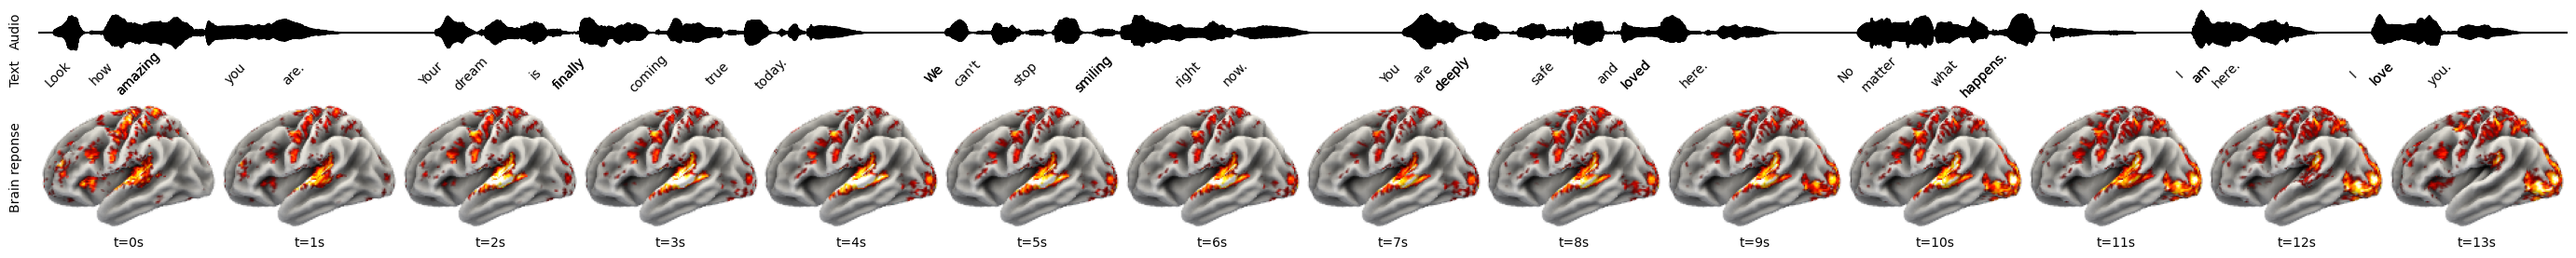

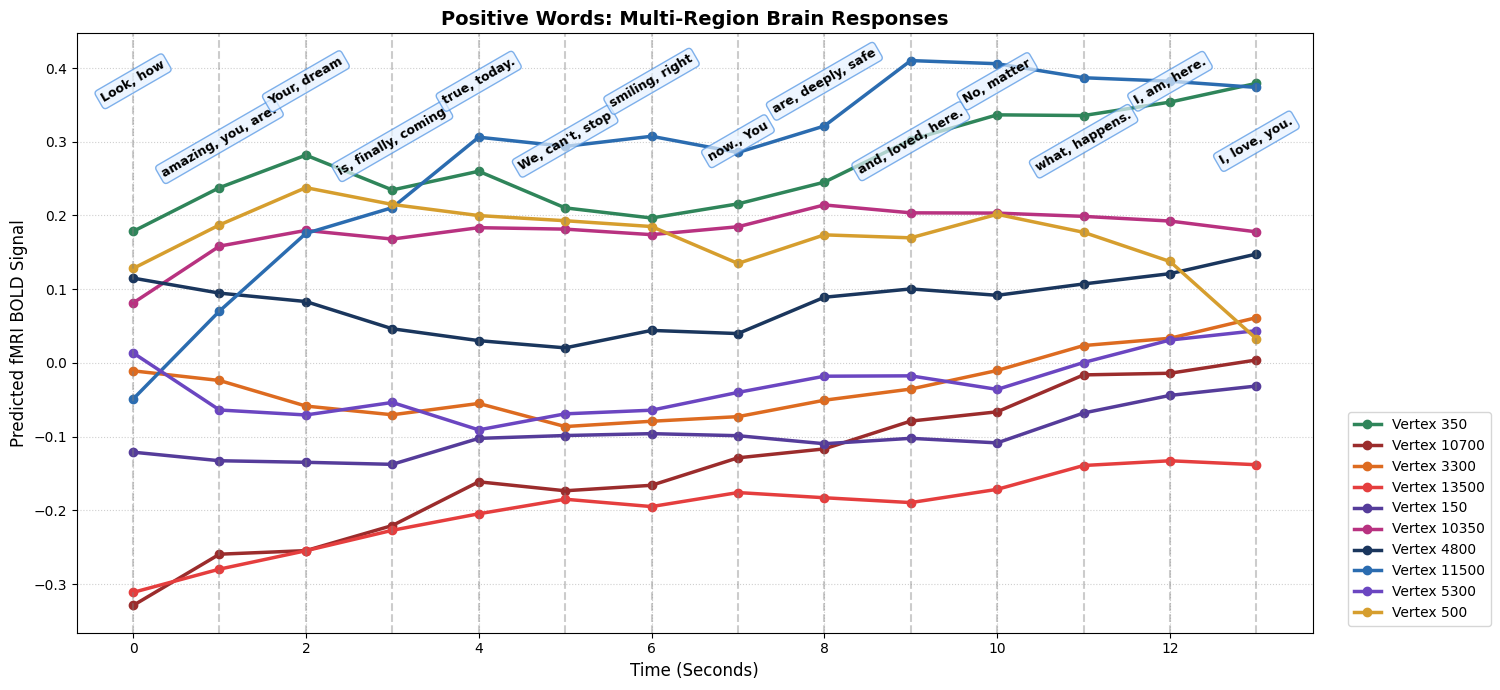


--- Negative Text Events ---


,type,start,duration,filepath,text,context
0,Audio,0.000000,13.776000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.110999,0.882002,NaN,You're useless.,
2,Text,0.111000,13.369000,NaN,You're useless. Such an absolute garbage. Fail...,
3,Word,0.111000,0.201000,NaN,You're,You're
4,Word,0.492000,0.501000,NaN,useless.,You're useless.
5,Sentence,1.613999,1.564002,NaN,Such an absolute garbage.,
6,Word,1.614000,0.221000,NaN,Such,You're useless. Such
7,Word,1.875000,0.080000,NaN,an,You're useless. Such an
8,Word,2.095000,0.482000,NaN,absolute,You're useless. Such an absolute
9,Word,2.617000,0.561000,NaN,garbage.,You're useless. Such an absolute garbage.


[07:56:03 WARNING] Removing extractor video as there are no corresponding events
[07:56:03 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:30<00:00,  1.05it/s]

Computing word embeddings: 100%|██████████| 8/8 [00:30<00:00,  3.80s/it]
[07:56:34 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[07:56:42 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-07-28 07:56:43 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[07:56:43 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:02<00:00,  2.61s/it]
INFO - Predicted 14 / 100 segments (14.0% kept)
INFO:tribev2.demo_utils:Predicted 14 / 100 segments (14.0% kept)


Predictions shape: (14, 20484)  (n_timesteps, n_vertices)


Plotting...: 100%|██████████| 14/14 [00:03<00:00,  3.72it/s]


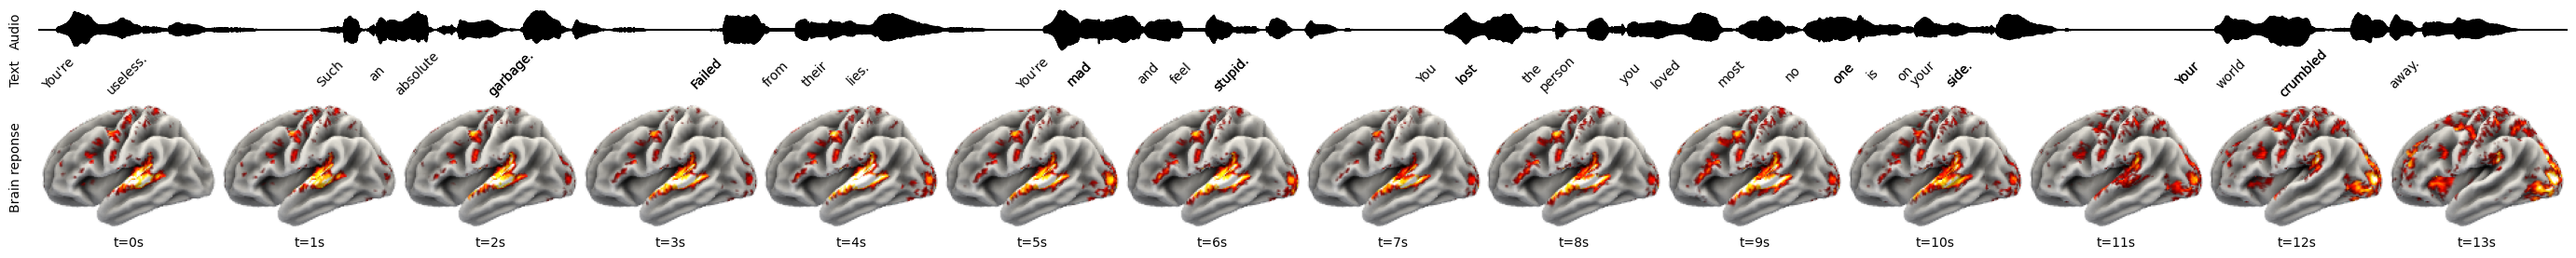

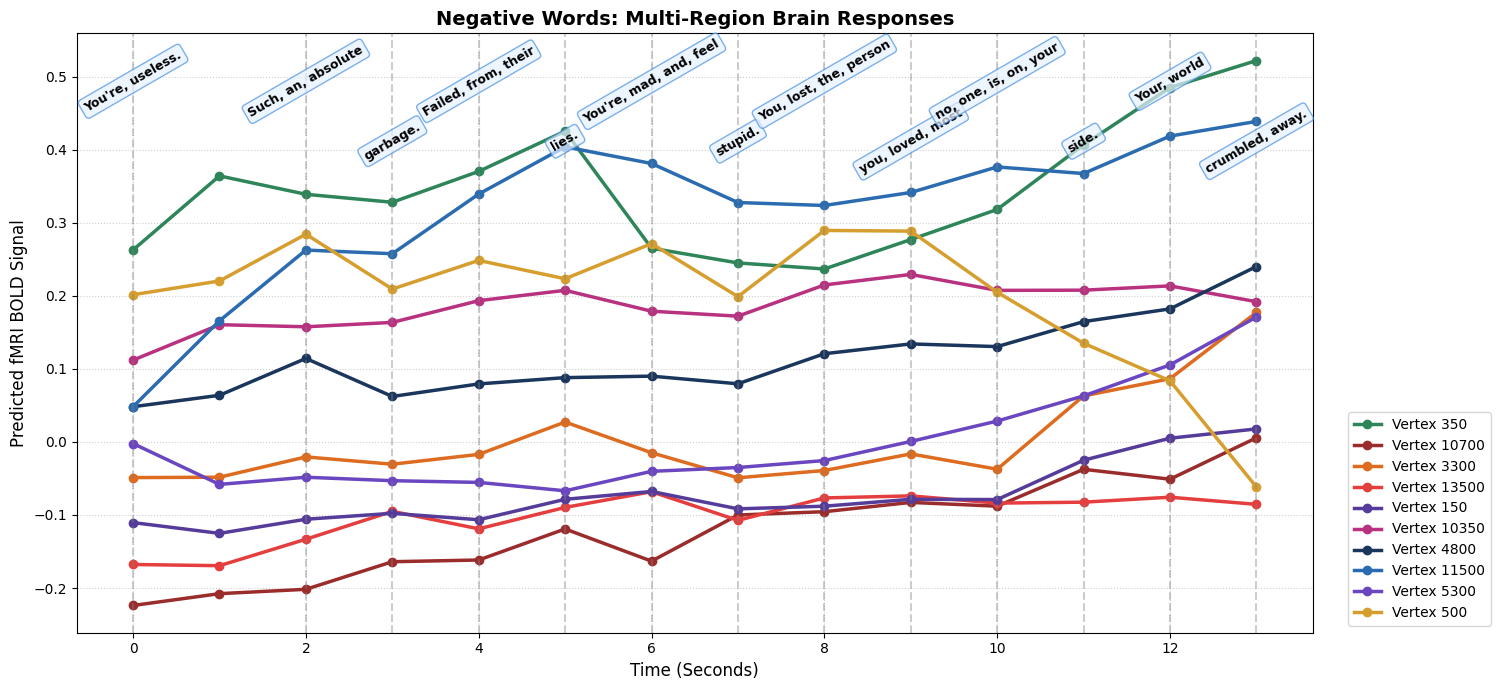

In [ ]:
# 설정값 정의
target_vertices = [350, 10700, 3300, 13500, 150, 10350, 4800, 11500, 5300, 500]
colors = ['#2f855a', '#9b2c2c', '#dd6b20', '#e53e3e', '#553c9a', '#b83280', '#1a365d', '#2b6cb0', '#6b46c1', '#d69e2e']

# 실행
preds_pos, df_pos = analyze_and_plot_brain_response(
    model, plotter, text_positive, 'positive', target_vertices, colors
)

preds_neg, df_neg = analyze_and_plot_brain_response(
    model, plotter, text_negative, 'negative', target_vertices, colors
)

## B. Visualization of Top 10 Vertices Most Sensitive to Linguistic Valence

In [ ]:
# update: 뇌과학적 Peak 탐색 로직 (In-Silico Contrast Search) ---
# top 10 vertex indices with the largest mean absolute difference between positive and negative activation across the entire time axis
# (시간축 전체에서 긍정과 부정의 활성화 차이(절대값)의 평균이 가장 큰 상위 5개 Vertex 인덱스 추출)
contrast = np.abs(preds_pos - preds_neg).mean(axis=0)
top_contrast_vertices = np.argsort(contrast)[-10:].tolist()

print(f"Top 10 Vertices Most Sensitive to Linguistic Valence: {top_contrast_vertices}")

Top 10 Vertices Most Sensitive to Linguistic Valence: [7050, 5142, 7924, 151, 2466, 3277, 5144, 5143, 2315, 9963]



--- Positive Text Events ---


,type,start,duration,filepath,text,context
0,Audio,0.000000,13.800000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.110999,1.423002,NaN,Look how amazing you are.,
2,Text,0.111000,13.326000,NaN,Look how amazing you are. Your dream is finall...,
3,Word,0.111000,0.201000,NaN,Look,Look
4,Word,0.352000,0.140000,NaN,how,Look how
5,Word,0.552000,0.481000,NaN,amazing,Look how amazing
6,Word,1.093000,0.140000,NaN,you,Look how amazing you
7,Word,1.414000,0.120000,NaN,are.,Look how amazing you are.
8,Sentence,2.174999,2.265002,NaN,Your dream is finally coming true today.,
9,Word,2.175000,0.161000,NaN,Your,Look how amazing you are. Your


[08:10:02 WARNING] Removing extractor video as there are no corresponding events
[08:10:02 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
[08:10:02 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio
[08:10:03 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-07-28 08:10:03 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[08:10:04 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoi

Predictions shape: (14, 20484)  (n_timesteps, n_vertices)


Plotting...: 100%|██████████| 14/14 [00:02<00:00,  5.65it/s]


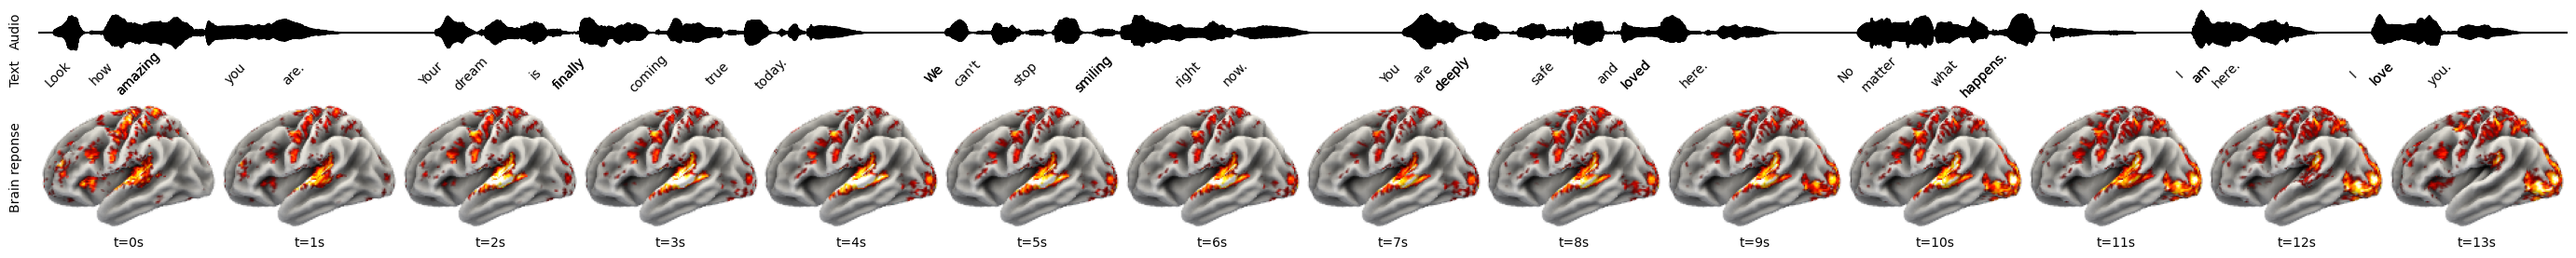

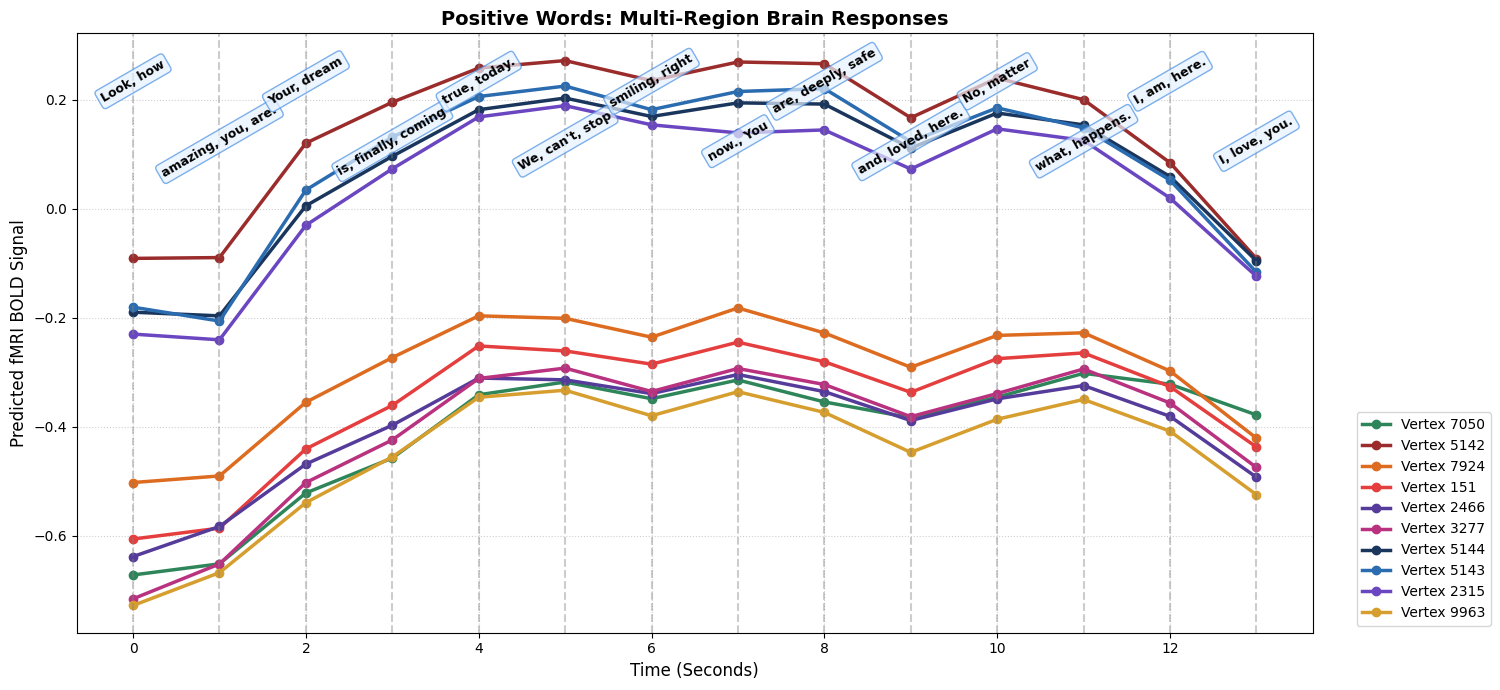


--- Negative Text Events ---


,type,start,duration,filepath,text,context
0,Audio,0.000000,13.776000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.110999,0.882002,NaN,You're useless.,
2,Text,0.111000,13.369000,NaN,You're useless. Such an absolute garbage. Fail...,
3,Word,0.111000,0.201000,NaN,You're,You're
4,Word,0.492000,0.501000,NaN,useless.,You're useless.
5,Sentence,1.613999,1.564002,NaN,Such an absolute garbage.,
6,Word,1.614000,0.221000,NaN,Such,You're useless. Such
7,Word,1.875000,0.080000,NaN,an,You're useless. Such an
8,Word,2.095000,0.482000,NaN,absolute,You're useless. Such an absolute
9,Word,2.617000,0.561000,NaN,garbage.,You're useless. Such an absolute garbage.


[08:10:10 WARNING] Removing extractor video as there are no corresponding events
[08:10:10 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
[08:10:10 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio
[08:10:11 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-07-28 08:10:11 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[08:10:11 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoi

Predictions shape: (14, 20484)  (n_timesteps, n_vertices)


Plotting...: 100%|██████████| 14/14 [00:02<00:00,  4.70it/s]


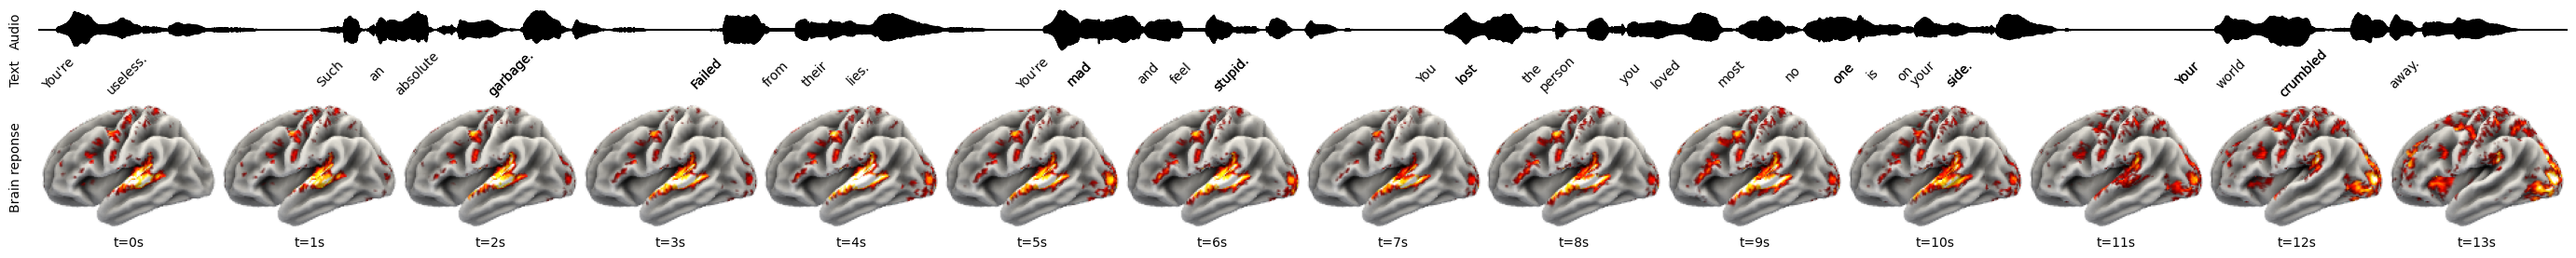

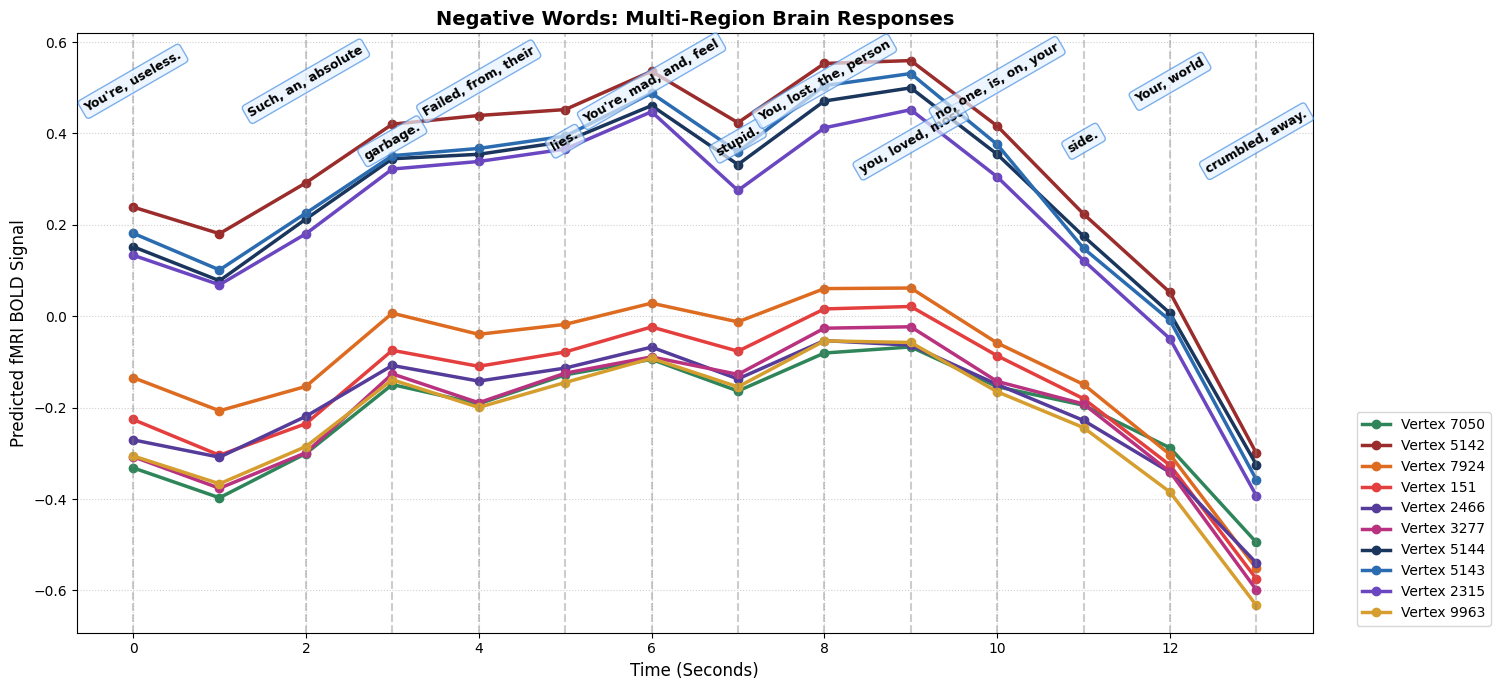

In [ ]:
# 설정값 정의
target_vertices = [7050, 5142, 7924, 151, 2466, 3277, 5144, 5143, 2315, 9963]
colors = ['#2f855a', '#9b2c2c', '#dd6b20', '#e53e3e', '#553c9a', '#b83280', '#1a365d', '#2b6cb0', '#6b46c1', '#d69e2e']

# 실행
preds_pos, df_pos = analyze_and_plot_brain_response(
    model, plotter, text_positive, 'positive', target_vertices, colors
)

preds_neg, df_neg = analyze_and_plot_brain_response(
    model, plotter, text_negative, 'negative', target_vertices, colors
)